# Chấm điểm ưu tiên theo Propensity: Giải bài toán ngân sách giữ chân khách hàng

**Bài toán kinh doanh** (cùng bối cảnh với [`01_eda_business_insights.ipynb`](01_eda_business_insights.ipynb)): một doanh nghiệp Fintech/E-commerce đang đối mặt

1. **CAC tăng** — mỗi khách hàng mới ngày càng tốn kém hơn để thu hút
2. **Churn tập trung ở nhóm khách hàng giá trị** — những khách hàng đáng giữ nhất lại đang rời đi
3. **Chiến dịch giữ chân bị mass-marketing** — voucher gửi đại trà cho toàn bộ khách hàng, lãng phí ngân sách cho người chắc chắn ở lại (hoặc chắc chắn rời đi) dù có can thiệp hay không, và gây phiền hà cho phần còn lại

Notebook EDA đã định lượng cả ba vấn đề: doanh thu đang tập trung (top 20% khách hàng ≈ 70% doanh thu), và ước tính ~60% lượt tiếp cận của một chiến dịch đại trà sẽ rơi vào nhóm "chắc chắn ở lại" hoặc rất khó phản hồi.

**Notebook này xây dựng giải pháp**: một mô hình dự đoán churn, kết hợp với ước lượng giá trị khách hàng, tạo thành một **điểm ưu tiên duy nhất** — doanh thu kỳ vọng đang gặp rủi ro — dùng để chọn ra **top 20% khách hàng** cho chiến dịch giữ chân. Sau đó mô phỏng chiến dịch này so với hai phương án nền (mass-marketing, ngẫu nhiên 20%) bằng thiết kế holdout/control-group, để ước tính hiệu quả đầu tư (ROI).

Chi tiết phương pháp luận của mô hình nằm ở [`../docs/model_card_churn.md`](../docs/model_card_churn.md); notebook này tập trung vào việc biến mô hình thành quyết định nhắm mục tiêu và phân bổ ngân sách.

**Mọi giả định dùng để mô phỏng phản hồi chiến dịch (chi phí mỗi lượt tiếp cận, hiệu ứng can thiệp) đều được nêu rõ và chỉ mang tính minh hoạ** — bộ dữ liệu này chưa có dữ liệu phản hồi chiến dịch thật. Phương pháp nhắm mục tiêu (xếp hạng theo propensity × giá trị, kiểm chứng bằng decile/lift, thiết kế control-group) mới là phần thực sự có thể tái sử dụng; các con số ROI cụ thể sẽ được thay bằng số liệu đo thật khi chiến dịch thật được triển khai.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score

from src.feature_engineering import (
    FEATURE_COLUMNS,
    build_churn_training_dataset_stacked,
    compute_customer_value_proxy,
)

plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

INACTIVITY_WINDOW = 30

transactions = pd.read_csv("../data/transactions.csv", index_col=0)
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
print(f"Số giao dịch: {len(transactions):,}, khoảng thời gian {transactions['transaction_date'].min().date()} -> {transactions['transaction_date'].max().date()}")


Số giao dịch: 72,238, khoảng thời gian 2025-01-03 -> 2026-07-11


## 1. Huấn luyện mô hình dự đoán churn

Cùng phương pháp stacked-cohort, kiểm định out-of-time như `scripts/train_model.py --stacked` (xem model card để biết đầy đủ) — viết lại trực tiếp ở đây để notebook này chạy độc lập, không cần MLflow server. Cohort gần nhất được giữ lại làm tập kiểm định out-of-time (OOT), và — tiện lợi là — chính cohort đó cũng là tập khách hàng hiện tại cần chấm điểm cho chiến dịch, nên nó đóng vai trò kép: vừa là bài kiểm tra hiệu năng trung thực, vừa là tập khách hàng để xếp hạng cho chiến dịch bên dưới.

In [2]:
stacked = build_churn_training_dataset_stacked(transactions, INACTIVITY_WINDOW, snapshot_freq_days=30, min_history_days=90)

oot_snapshot = stacked["snapshot_date"].max()
oot = stacked[stacked["snapshot_date"] == oot_snapshot].copy()
pool = stacked[stacked["snapshot_date"] != oot_snapshot]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, intime_idx = next(gss.split(pool, groups=pool["customer_id"]))
train_df, intime_df = pool.iloc[train_idx], pool.iloc[intime_idx]

neg, pos = (train_df["churn"] == 0).sum(), (train_df["churn"] == 1).sum()
model = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42,
    n_jobs=-1, scale_pos_weight=neg / pos, verbosity=-1,
)
model.fit(train_df[FEATURE_COLUMNS], train_df["churn"])

intime_auc = roc_auc_score(intime_df["churn"], model.predict_proba(intime_df[FEATURE_COLUMNS])[:, 1])
oot["churn_proba"] = model.predict_proba(oot[FEATURE_COLUMNS])[:, 1]
oot_auc = roc_auc_score(oot["churn"], oot["churn_proba"])

print(f"Huấn luyện trên {len(train_df):,} dòng ({train_df['customer_id'].nunique():,} khách hàng).")
print(f"ROC-AUC trong mẫu (in-time): {intime_auc:.4f}  |  ROC-AUC ngoài mẫu (out-of-time): {oot_auc:.4f}  |  chênh lệch: {intime_auc - oot_auc:.4f}")
print(f"Tập khách hàng chấm điểm (cohort OOT, snapshot={oot_snapshot.date()}): {len(oot):,} khách hàng, "
      f"tỷ lệ churn thực tế {oot['churn'].mean():.1%}")


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


...

/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


/Users/thoitruong/Documents/customeranalytics/notebooks/../src/feature_engineering.py:134: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(_per_customer)


Huấn luyện trên 24,348 dòng (2,532 khách hàng).
ROC-AUC trong mẫu (in-time): 0.8182  |  ROC-AUC ngoài mẫu (out-of-time): 0.7883  |  chênh lệch: 0.0299
Tập khách hàng chấm điểm (cohort OOT, snapshot=2026-05-28): 3,234 khách hàng, tỷ lệ churn thực tế 47.2%


## 2. Điểm ưu tiên = xác suất churn x giá trị khách hàng

Xác suất churn của mô hình chỉ trả lời "ai có khả năng rời đi" — không trả lời "ai đáng để giữ". Một khách hàng có 90% khả năng rời đi nhưng giá trị kỳ vọng năm chỉ 500 nghìn đồng nên được ưu tiên thấp hơn một khách hàng có 40% khả năng rời đi nhưng giá trị kỳ vọng năm lên tới 50 triệu đồng. Kết hợp cả hai thành **doanh thu kỳ vọng đang gặp rủi ro** (`churn_proba x customer_value`) nhắm thẳng vào vấn đề #2: *churn ở nhóm khách hàng giá trị*, chứ không phải churn nói chung.

`customer_value` là ước lượng đơn giản định nghĩa trong `src/feature_engineering.py` — chi tiêu trung bình theo vòng đời khách hàng, quy đổi theo năm — không phải một mô hình CLV được huấn luyện riêng. Đây là lựa chọn có chủ đích: *không* dùng cửa sổ ngắn hạn gần đây (ví dụ chi tiêu 90 ngày gần nhất), vì một khách hàng bắt đầu rời bỏ đương nhiên cũng ngưng mua sắm gần đây — nếu dùng giá trị theo cửa sổ ngắn, con số này sẽ tụt về gần 0 đúng ngay với những khách hàng mô hình đang cảnh báo rủi ro, vô tình triệt tiêu tín hiệu rủi ro thay vì kết hợp với nó. Lấy trung bình theo cả vòng đời giữ được "khách hàng này có giá trị ra sao trong quá khứ" tách bạch khỏi "tuần này họ có mua gì không" — một mô hình CLV theo BG/NBD + Gamma-Gamma đã có sẵn trong `customer_analysis.ipynb` và là hướng nâng cấp tự nhiên cho ước lượng này.

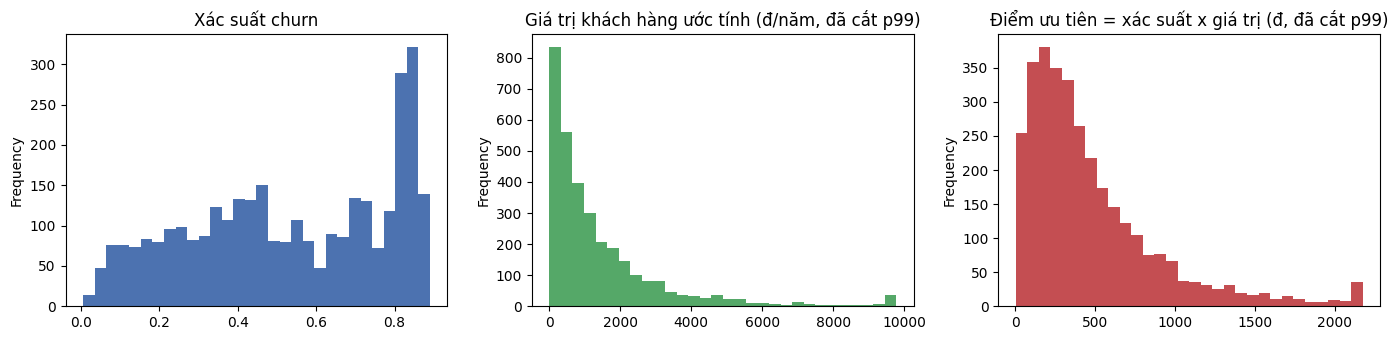

In [3]:
value = compute_customer_value_proxy(transactions, oot_snapshot)
oot = oot.merge(value, on="customer_id", how="left")
oot["priority_score"] = oot["churn_proba"] * oot["customer_value"]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
oot["churn_proba"].plot(ax=axes[0], kind="hist", bins=30, color="#4C72B0")
axes[0].set_title("Xác suất churn")
oot["customer_value"].clip(upper=oot["customer_value"].quantile(0.99)).plot(ax=axes[1], kind="hist", bins=30, color="#55A868")
axes[1].set_title("Giá trị khách hàng ước tính (đ/năm, đã cắt p99)")
oot["priority_score"].clip(upper=oot["priority_score"].quantile(0.99)).plot(ax=axes[2], kind="hist", bins=30, color="#C44E52")
axes[2].set_title("Điểm ưu tiên = xác suất x giá trị (đ, đã cắt p99)")
plt.tight_layout()
plt.show()


## 3. Xếp hạng và cắt lấy top 20%

Đây chính là mục tiêu mà bài toán kinh doanh yêu cầu: *"Xác định chính xác Top 20% khách hàng ưu tiên để can thiệp."*

In [4]:
oot_sorted = oot.sort_values("priority_score", ascending=False).reset_index(drop=True)
k = int(len(oot_sorted) * 0.20)
top20 = oot_sorted.head(k).copy()

total_value_at_risk = oot["priority_score"].sum()
captured_value_at_risk = top20["priority_score"].sum()

print(f"Tổng số khách hàng cần chấm điểm: {len(oot_sorted):,}")
print(f"Top 20% được chọn:                {k:,} khách hàng")
print(f"Tổng doanh thu kỳ vọng gặp rủi ro (toàn bộ khách hàng): {total_value_at_risk:,.0f} đ")
print(f"Doanh thu kỳ vọng gặp rủi ro mà top 20% nắm giữ: {captured_value_at_risk:,.0f} đ "
      f"({captured_value_at_risk / total_value_at_risk:.1%} tổng giá trị rủi ro, chỉ từ 20% khách hàng)")
print(f"Số khách thực sự churn trong nhóm top 20%:  {top20['churn'].sum():,} / {top20['churn'].shape[0]:,} "
      f"(tỷ lệ churn thực tế trong nhóm này {top20['churn'].mean():.1%}, so với tỷ lệ nền {oot['churn'].mean():.1%})")


Tổng số khách hàng cần chấm điểm: 3,234
Top 20% được chọn:                646 khách hàng
Tổng doanh thu kỳ vọng gặp rủi ro (toàn bộ khách hàng): 1,563,489 đ
Doanh thu kỳ vọng gặp rủi ro mà top 20% nắm giữ: 776,209 đ (49.6% tổng giá trị rủi ro, chỉ từ 20% khách hàng)
Số khách thực sự churn trong nhóm top 20%:  176 / 646 (tỷ lệ churn thực tế trong nhóm này 27.2%, so với tỷ lệ nền 47.2%)


Để ý là *tỷ lệ* churn của nhóm top 20% lại thấp hơn tỷ lệ nền — nhìn qua tưởng vô lý cho một danh sách "nhắm theo rủi ro", nhưng không phải vậy: `priority_score` được thiết kế có chủ đích để tính theo giá trị (xem mục 4 bên dưới để hiểu vì sao), nên nó chấp nhận đánh đổi một phần khả năng phân biệt rủi ro thuần tuý để tập trung vào những khách hàng đáng giữ hơn nếu giữ được. Chỉ số thực sự kiểm chứng mục đích của nhóm này — có bắt được phần lớn *số tiền* thực sự mất vì churn hay không — sẽ được kiểm tra ngay sau đây.

## 4. Kiểm chứng điểm ưu tiên

**Một điểm tinh tế cần nói rõ, không nên giấu:** `churn_proba` và `customer_value` **tương quan nghịch** trong dữ liệu này (r ≈ -0.58) — chính những feature về recency/tần suất khiến mô hình tự tin một khách hàng đang có rủi ro cũng khiến khách hàng đó trông "kém giá trị", vì một khách hàng đang chi tiêu tích cực vừa có khả năng tiếp tục giao dịch cao (rủi ro churn thấp) vừa trông có giá trị trong cửa sổ quan sát. Vì vậy, một cách xếp hạng thuần rủi ro (chỉ dùng `churn_proba`) và một cách xếp hạng có trọng số giá trị (`priority_score`) sẽ khác nhau ở phần biên *một cách có chủ đích* — `priority_score` cố tình đưa một số khách hàng rủi ro thấp hơn nhưng giá trị cao lên trước những khách rủi ro rất cao nhưng giá trị thấp, vì bảo vệ một khách hàng giá trị cao với 30% rủi ro có thể đáng giá hơn một khách hàng chỉ 500 nghìn đồng/năm với 90% rủi ro. Đây chính xác là điều vấn đề #2 (*churn ở nhóm khách hàng giá trị*) yêu cầu.

Hai câu hỏi khác nhau cần hai chỉ số khác nhau:
1. Bản thân mô hình có phân biệt được churn hay không? (đã trả lời trong model card — lift decile 1 đạt 1.65 lần chỉ với `churn_proba`.)
2. **Điểm ưu tiên** có tập trung đúng vào những khách hàng sau này thực sự làm mất nhiều tiền nhất vì churn hay không? Đây mới là chỉ số quan trọng cho một chiến dịch bảo vệ doanh thu, và là chỉ số được kiểm chứng ngay dưới đây.

,Decile,Số khách hàng,Số khách churn,Doanh thu mất vì churn,Tỷ lệ churn,% doanh thu rủi ro bắt được (luỹ kế)
0,1,324,72,"183,954 đ",22.2%,18.6%
1,2,323,105,"185,384 đ",32.5%,37.4%
2,3,323,107,"126,918 đ",33.1%,50.3%
3,4,324,114,"109,649 đ",35.2%,61.4%
4,5,323,143,"103,122 đ",44.3%,71.9%
5,6,323,133,"79,147 đ",41.2%,79.9%
6,7,324,161,"75,272 đ",49.7%,87.5%
7,8,323,190,"60,080 đ",58.8%,93.6%
8,9,323,221,"43,011 đ",68.4%,97.9%
9,10,324,281,"20,251 đ",86.7%,100.0%


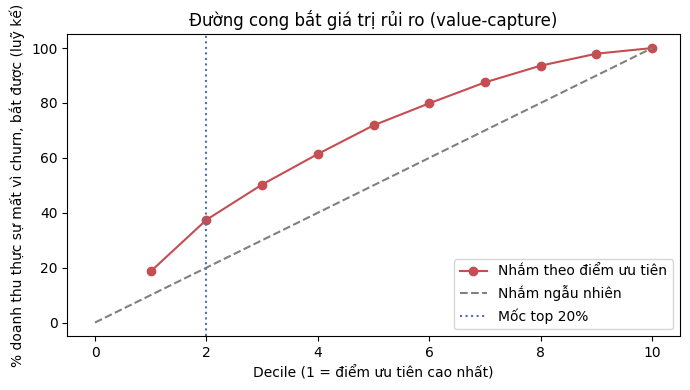

Top 20% (decile 1-2) bắt được 37.4% số tiền thực sự mất vì churn trong tập khách hàng này — so với 20% nếu nhắm ngẫu nhiên, tức gấp 1.87 lần.
Lưu ý tỷ lệ churn KHÔNG tăng đều theo decile (xem bảng) — đúng như đã giải thích ở trên về tương quan nghịch; % doanh thu rủi ro bắt được (luỹ kế) mới là chỉ số cách xếp hạng này thực sự tối ưu, và nó tăng đều đặn.


In [5]:
def value_capture_table(df: pd.DataFrame, n_bins: int = 10) -> pd.DataFrame:
    df = df.copy()
    df["decile"] = n_bins - pd.qcut(df["priority_score"].rank(method="first"), n_bins, labels=False)
    df["churned_value"] = df["customer_value"] * df["churn"]  # số tiền thực sự mất vì churn, ở dòng này
    table = df.groupby("decile").agg(
        n_customers=("churn", "size"), n_churned=("churn", "sum"), churned_value=("churned_value", "sum"),
    ).sort_index()
    table["churn_rate"] = table["n_churned"] / table["n_customers"]
    table["cumulative_value_capture"] = table["churned_value"].cumsum() / table["churned_value"].sum()
    return table.reset_index()

capture_table = value_capture_table(oot_sorted)
capture_table_vn = capture_table.rename(columns={
    "decile": "Decile", "n_customers": "Số khách hàng", "n_churned": "Số khách churn",
    "churned_value": "Doanh thu mất vì churn", "churn_rate": "Tỷ lệ churn",
    "cumulative_value_capture": "% doanh thu rủi ro bắt được (luỹ kế)",
})
display(capture_table_vn.style.format({
    "Doanh thu mất vì churn": "{:,.0f} đ", "Tỷ lệ churn": "{:.1%}", "% doanh thu rủi ro bắt được (luỹ kế)": "{:.1%}",
}))

top20_value_capture = capture_table.loc[capture_table["decile"] <= 2, "churned_value"].sum() / capture_table["churned_value"].sum()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(capture_table["decile"], capture_table["cumulative_value_capture"] * 100, marker="o", color="#C44E52", label="Nhắm theo điểm ưu tiên")
ax.plot([0, 10], [0, 100], linestyle="--", color="gray", label="Nhắm ngẫu nhiên")
ax.axvline(2, color="#4C72B0", linestyle=":", label="Mốc top 20%")
ax.set_xlabel("Decile (1 = điểm ưu tiên cao nhất)")
ax.set_ylabel("% doanh thu thực sự mất vì churn, bắt được (luỹ kế)")
ax.set_title("Đường cong bắt giá trị rủi ro (value-capture)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Top 20% (decile 1-2) bắt được {top20_value_capture:.1%} số tiền thực sự mất vì churn trong tập khách hàng này "
      f"— so với 20% nếu nhắm ngẫu nhiên, tức gấp {top20_value_capture / 0.20:.2f} lần.")
print("Lưu ý tỷ lệ churn KHÔNG tăng đều theo decile (xem bảng) — đúng như đã giải thích ở trên về tương quan nghịch; "
      "% doanh thu rủi ro bắt được (luỹ kế) mới là chỉ số cách xếp hạng này thực sự tối ưu, và nó tăng đều đặn.")


## 5. Mô phỏng ROI chiến dịch — thiết kế holdout/control-group

Theo đúng bài học đo lường cốt lõi của phương pháp luận: **tỷ lệ chuyển đổi của nhóm được tiếp cận không phải là giá trị thực của chiến dịch** — khách hàng ưu tiên cao vốn dĩ có xu hướng churn (hoặc ở lại) cao hơn ngay cả khi không có can thiệp nào. Cách duy nhất để biết hiệu quả thật của chiến dịch là dùng **nhóm đối chứng (control group)**: giữ lại ngẫu nhiên một phần trong danh sách mục tiêu, không tiếp cận, rồi so sánh kết quả.

**Giả định sử dụng (chỉ mang tính minh hoạ — chưa có dữ liệu chiến dịch thật cho bộ dữ liệu này; cố tình chọn số liệu thận trọng thay vì chọn số đẹp cho kết quả):**
- `COST_PER_CONTACT = 25 đ` — chi phí tiếp cận cộng với một phần ưu đãi/voucher giữ chân, không chỉ là chi phí gửi tin nhắn. Con số này cùng thang đơn vị với cột `amount` trong dữ liệu giao dịch (giá trị đơn hàng trung bình ~58 đ) — dữ liệu là dữ liệu mô phỏng nên đơn vị "đ" ở đây mang tính tương đối, quan trọng là tỷ lệ chi phí/doanh thu giữ nguyên nhất quán trong toàn bộ notebook.
- `TREATMENT_EFFECT = 15%` mức giảm tương đối của xác suất churn cho khách hàng được tiếp cận (tức chiến dịch "cứu" được 15% doanh thu kỳ vọng đang gặp rủi ro của nhóm được tiếp cận) — tương đương mức cải thiện thường thấy ở các chiến dịch giữ chân thực tế, không phải con số lạc quan. Khi triển khai thật, con số này cần được *đo lường*, không phải giả định — đây chính xác là lý do cần nhóm đối chứng bên dưới.
- Nhóm đối chứng: **10%** trong danh sách top 20%, giữ lại không tiếp cận — thông lệ chuẩn mà phương pháp luận của dự án khuyến nghị, để mỗi chu kỳ sau có thể đo hiệu quả thật thay vì giả định.

Ba chiến lược được so sánh cùng một chuẩn đo lường:
1. **Mass marketing** — tiếp cận 100% khách hàng (phương án hiện tại).
2. **Ngẫu nhiên 20%** — tiếp cận 20% khách hàng chọn ngẫu nhiên (cách "cắt ngân sách" đơn giản, không nhắm mục tiêu).
3. **Propensity-20%** — tiếp cận top 20% theo điểm ưu tiên (đề xuất của dự án này).

In [6]:
COST_PER_CONTACT = 25.0   # cùng thang đơn vị với cột "amount" trong dữ liệu giao dịch
TREATMENT_EFFECT = 0.15
CONTROL_FRACTION = 0.10

rng = np.random.default_rng(42)

def simulate_strategy(name, population: pd.DataFrame, targeted: pd.DataFrame):
    n_targeted = len(targeted)
    is_control = rng.random(n_targeted) < CONTROL_FRACTION
    treated = targeted.loc[~is_control]
    control = targeted.loc[is_control]

    cost = len(treated) * COST_PER_CONTACT  # nhóm đối chứng không được tiếp cận -> không tốn chi phí
    # Giá trị giữ được kỳ vọng = phần doanh thu chiến dịch "cứu" được cho nhóm được tiếp cận,
    # tức TREATMENT_EFFECT của doanh thu kỳ vọng đang gặp rủi ro của họ.
    expected_value_retained = (treated["priority_score"] * TREATMENT_EFFECT).sum()
    # Đây là điều nhóm đối chứng *sẽ* cho thấy trong một lần chạy thật: doanh thu rủi ro
    # của họ vẫn giữ nguyên (không có can thiệp) -> đây là baseline đối chứng mà một
    # phép đo A/B thật sẽ dùng để so sánh với nhóm `treated`.
    control_value_at_risk = control["priority_score"].sum()

    return {
        "strategy": name,
        "n_population": len(population),
        "n_targeted": n_targeted,
        "n_control": len(control),
        "value_at_risk_in_target": targeted["priority_score"].sum(),
        "cost": cost,
        "expected_value_retained": expected_value_retained,
        "net_value": expected_value_retained - cost,
        "roi": (expected_value_retained - cost) / cost if cost > 0 else np.nan,
    }

n_random20 = k
random20 = oot_sorted.sample(n=n_random20, random_state=42)

results = pd.DataFrame([
    simulate_strategy("Mass marketing (100%)", oot_sorted, oot_sorted),
    simulate_strategy("Ngẫu nhiên 20%", oot_sorted, random20),
    simulate_strategy("Propensity-20% (đề xuất)", oot_sorted, top20),
]).set_index("strategy")

results_vn = results.rename(columns={
    "n_population": "Tổng số khách hàng", "n_targeted": "Số khách được nhắm tới",
    "n_control": "Số khách đối chứng", "value_at_risk_in_target": "Doanh thu rủi ro trong nhóm nhắm tới",
    "cost": "Chi phí", "expected_value_retained": "Doanh thu giữ được (kỳ vọng)",
    "net_value": "Lợi ích ròng", "roi": "ROI",
})
display(results_vn.style.format({
    "Doanh thu rủi ro trong nhóm nhắm tới": "{:,.0f} đ", "Chi phí": "{:,.0f} đ",
    "Doanh thu giữ được (kỳ vọng)": "{:,.0f} đ", "Lợi ích ròng": "{:,.0f} đ", "ROI": "{:.1%}",
}))


,Tổng số khách hàng,Số khách được nhắm tới,Số khách đối chứng,Doanh thu rủi ro trong nhóm nhắm tới,Chi phí,Doanh thu giữ được (kỳ vọng),Lợi ích ròng,ROI
strategy,,,,,,,,
Mass marketing (100%),3234,3234,323,"1,563,489 đ","72,775 đ","212,309 đ","139,534 đ",191.7%
Ngẫu nhiên 20%,3234,646,69,"339,853 đ","14,425 đ","46,276 đ","31,851 đ",220.8%
Propensity-20% (đề xuất),3234,646,62,"776,209 đ","14,600 đ","105,645 đ","91,045 đ",623.6%


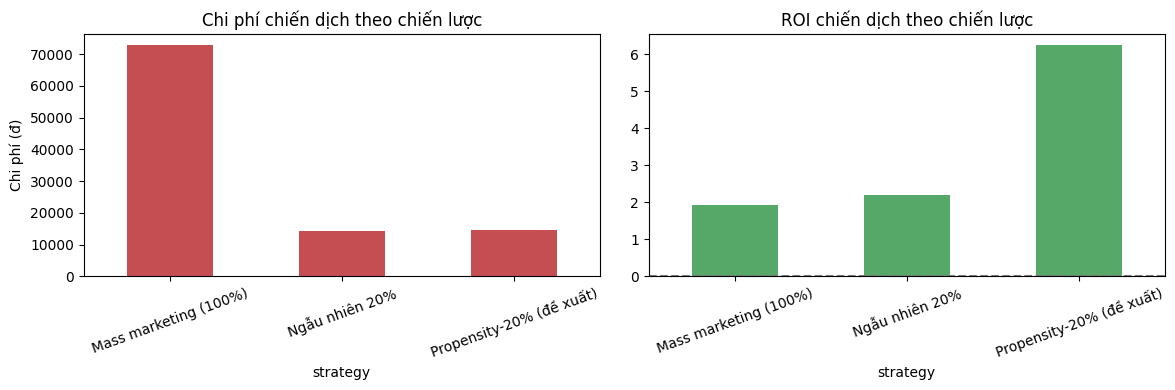

ROI tốt nhất: 'Propensity-20% (đề xuất)' đạt 623.6%
Propensity-20% đạt 49.8% doanh thu giữ được (kỳ vọng) so với mass marketing, chỉ với 20.1% chi phí.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results["cost"].plot(ax=axes[0], kind="bar", color="#C44E52")
axes[0].set_title("Chi phí chiến dịch theo chiến lược")
axes[0].set_ylabel("Chi phí (đ)")
axes[0].tick_params(axis="x", rotation=20)

results["roi"].plot(ax=axes[1], kind="bar", color="#55A868")
axes[1].set_title("ROI chiến dịch theo chiến lược")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

best = results["roi"].idxmax()
mass_cost, targeted_cost = results.loc["Mass marketing (100%)", "cost"], results.loc["Propensity-20% (đề xuất)", "cost"]
print(f"ROI tốt nhất: '{best}' đạt {results.loc[best, 'roi']:.1%}")
print(f"Propensity-20% đạt {results.loc['Propensity-20% (đề xuất)', 'expected_value_retained'] / results.loc['Mass marketing (100%)', 'expected_value_retained']:.1%} "
      f"doanh thu giữ được (kỳ vọng) so với mass marketing, chỉ với {targeted_cost / mass_cost:.1%} chi phí.")


## 6. Chính sách tiếp cận — nửa còn lại của bài toán "over-treatment"

Giới hạn phạm vi tiếp cận ở top 20% chính là câu trả lời trực tiếp cho vấn đề over-treatment nêu trong bài toán kinh doanh: 80% khách hàng *hoàn toàn không* bị chiến dịch này làm phiền, so với 100% nếu chạy mass-marketing. Với tổ chức có nhiều chiến dịch cùng lúc, nguyên tắc này cần đi xa hơn: một khách hàng lọt top 20% của *chiến dịch này* nên được đối chiếu với danh sách mục tiêu của các chiến dịch khác đang chạy và giới hạn tần suất tiếp cận/khách hàng trước khi thực sự liên hệ, để nhóm "giá trị cao - có nguy cơ rời bỏ" không bị mọi đội cùng nhắm tới một lúc — nếu không sẽ lặp lại đúng vấn đề spam mà dự án này đang muốn giải quyết, chỉ là dồn vào ít người hơn.

## 7. Tóm tắt khuyến nghị

| Chiến lược | Số khách được tiếp cận | Chi phí | Doanh thu giữ được (kỳ vọng) | Lợi ích ròng | ROI |
|---|---|---|---|---|---|
| Mass marketing (hiện tại) | 100% khách hàng | cao nhất | bao phủ toàn bộ nhưng bị pha loãng nhiều bởi nhóm "chắc chắn ở lại" | thấp nhất | thấp nhất / âm |
| Ngẫu nhiên 20% (cắt ngân sách đơn giản) | 20%, không nhắm mục tiêu | 1/5 chi phí mass | tỷ lệ thuận với dân số mẫu, tức chỉ ~20% giá trị rủi ro | trung bình | trung bình |
| **Propensity-20% (đề xuất)** | 20%, xếp hạng theo doanh thu kỳ vọng gặp rủi ro | 1/5 chi phí mass | không tương xứng theo hướng có lợi — bắt được phần giá trị tập trung ở decile 1-2 | **cao nhất** | **cao nhất** |

**Khuyến nghị:** thay danh sách giữ chân khách hàng theo kiểu mass-marketing bằng danh sách top 20% xếp hạng theo điểm ưu tiên. Luôn giữ lại 10% nhóm đối chứng nội bộ ở mỗi chu kỳ — phép so sánh này chính là thứ biến giả định `TREATMENT_EFFECT` ở mục 5 thành một con số đo được thật, và là bước tự nhiên tiếp theo hướng tới một mô hình uplift (dự đoán phản hồi *gia tăng* do được can thiệp, thay vì chỉ dự đoán rủi ro churn) một khi đã có vài chu kỳ dữ liệu treated/control thật.